# ENDF Data Loading

NEREIDS fetches evaluated nuclear data from the IAEA database and caches it
locally.  This notebook covers the three ways to get resonance data into memory:

| Function | Source |
|----------|--------|
| `load_endf(z, a)` | Download from IAEA + local cache |
| `load_endf_file(path)` | Parse a local ENDF file |
| `create_resonance_data(..., l_groups=)` | Manual construction for multiple L-groups |

## Prerequisites

```bash
pixi run build
```

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Resolve paths relative to the repo root regardless of where Jupyter was launched.
def _repo_root() -> pathlib.Path:
    """Walk up from CWD until Cargo.toml (the repo root marker) is found."""
    for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (p / 'Cargo.toml').exists():
            return p
    raise RuntimeError("Cannot locate repo root: Cargo.toml not found above CWD")

## 1. Loading U-238 from the IAEA

The `load_endf()` function downloads an ENDF file from the IAEA Nuclear Data
Services, parses the resonance parameters (MF=2, MT=151), and returns a
`ResonanceData` object. Files are cached at `~/.cache/nereids/endf/` so
subsequent calls are instant.

The default library is **ENDF/B-VIII.1** (latest release, Aug 2024).
ENDF/B-VIII.0, JEFF-3.3, and JENDL-5 are also available.

In [2]:
# Fetch U-238 from IAEA (or cache)
u238 = nereids.load_endf(92, 238)
print(u238)
print(f"  L values:          {u238.l_values}")
print(f"  Target spin:       {u238.target_spin}")
print(f"  Scattering radius: {u238.scattering_radius}")
print(f"  Total resonances:  {u238.n_resonances}")

ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=3345)
  L values:          [0, 1]
  Target spin:       0.0
  Scattering radius: 9.48
  Total resonances:  3345


U-238 has **two L-groups** (L=0 s-wave and L=1 p-wave) with thousands of
resonances. Compare this to notebook 01 where we manually entered a single
resonance at 6.674 eV.

## 2. Full ENDF vs Single-Resonance Cross-Sections

Let's compare the full ENDF U-238 cross-sections against the single-resonance
approximation from notebook 01.

In [3]:
# Single-resonance model from notebook 01
u238_single = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Energy grid: 1–50 eV (covers many resonances)
energies = np.geomspace(1.0, 50.0, 5000)

# Compute cross-sections
xs_full = nereids.cross_sections(energies, u238)
xs_single = nereids.cross_sections(energies, u238_single)

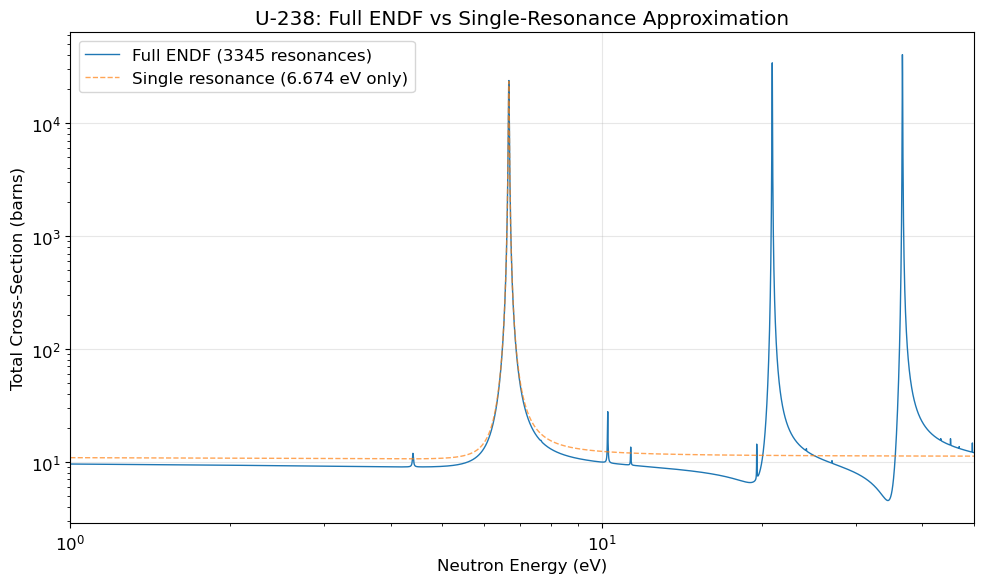

In [4]:
fig, ax = plt.subplots()
ax.loglog(energies, xs_full['total'], label='Full ENDF (3345 resonances)', linewidth=1.0)
ax.loglog(energies, xs_single['total'], '--', label='Single resonance (6.674 eV only)',
          linewidth=1.0, alpha=0.7)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238: Full ENDF vs Single-Resonance Approximation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

The full ENDF data reveals a rich forest of resonances above ~6 eV, each
corresponding to a compound nuclear state. The single-resonance model only
captures the dominant 6.674 eV peak.

## 3. Loading Pu-241

NEREIDS has **535 built-in MAT numbers** covering all ground-state isotopes in
the ENDF/B-VIII.0 neutrons sublibrary, so `load_endf(z, a)` works for the
vast majority of isotopes without any additional arguments.

The `mat=` keyword is only needed for isotopes outside that set (e.g. metastable
states or isotopes unique to JEFF/JENDL that were not in ENDF/B-VIII.0).

In [5]:
# Pu-241: important for spent fuel characterization
pu241 = nereids.load_endf(94, 241)
print(pu241)
print(f"  L values:          {pu241.l_values}")
print(f"  Target spin:       {pu241.target_spin}")
print(f"  Total resonances:  {pu241.n_resonances}")

ResonanceData(Z=94, A=241, AWR=238.978, n_resonances=243)
  L values:          [0]
  Target spin:       2.5
  Total resonances:  243


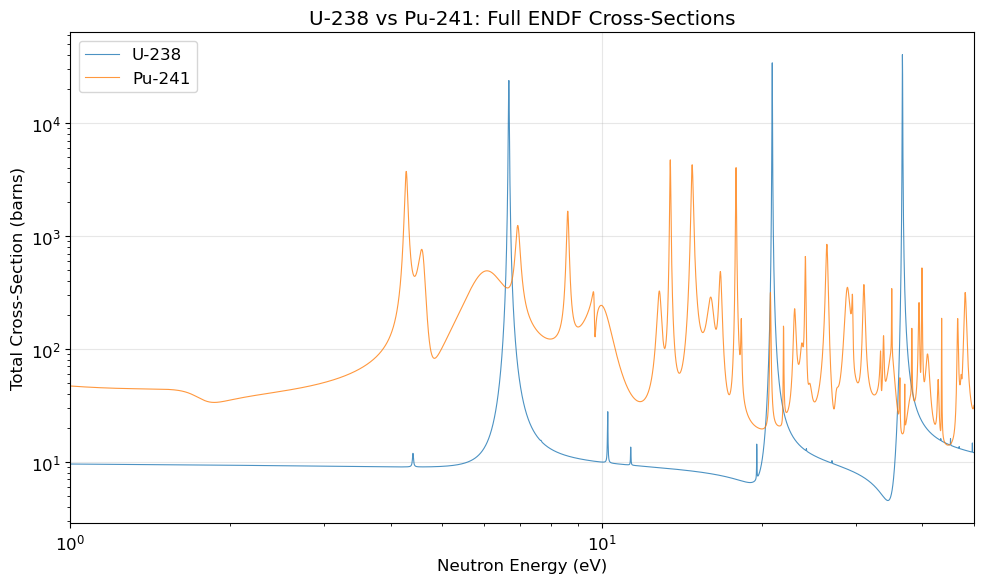

In [6]:
# Compare U-238 and Pu-241 total cross-sections
xs_pu241 = nereids.cross_sections(energies, pu241)

fig, ax = plt.subplots()
ax.loglog(energies, xs_full['total'], label='U-238', linewidth=0.8, alpha=0.8)
ax.loglog(energies, xs_pu241['total'], label='Pu-241', linewidth=0.8, alpha=0.8)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238 vs Pu-241: Full ENDF Cross-Sections')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 4. Transmission with Full ENDF Data

The real power of loading full ENDF data is computing realistic transmission
spectra. This is the fundamental measurement in neutron resonance imaging.

In [7]:
# Compute transmission for a sample with both isotopes
# Areal densities matching the PLEIADES test data:
#   U-235: 0.001025 atoms/barn
#   Pu-241: 0.0004998 atoms/barn

u235 = nereids.load_endf(92, 235)
print(u235)
print(f"  L values: {u235.l_values}, Target spin: {u235.target_spin}, Resonances: {u235.n_resonances}")

# Forward model: Beer-Lambert with Doppler broadening at 293.6 K
transmission = nereids.forward_model(
    energies,
    [(u235, 0.001025), (pu241, 0.0004998)],
    temperature_k=293.6,
)

ResonanceData(Z=92, A=235, AWR=233.025, n_resonances=3194)
  L values: [0], Target spin: 3.5, Resonances: 3194


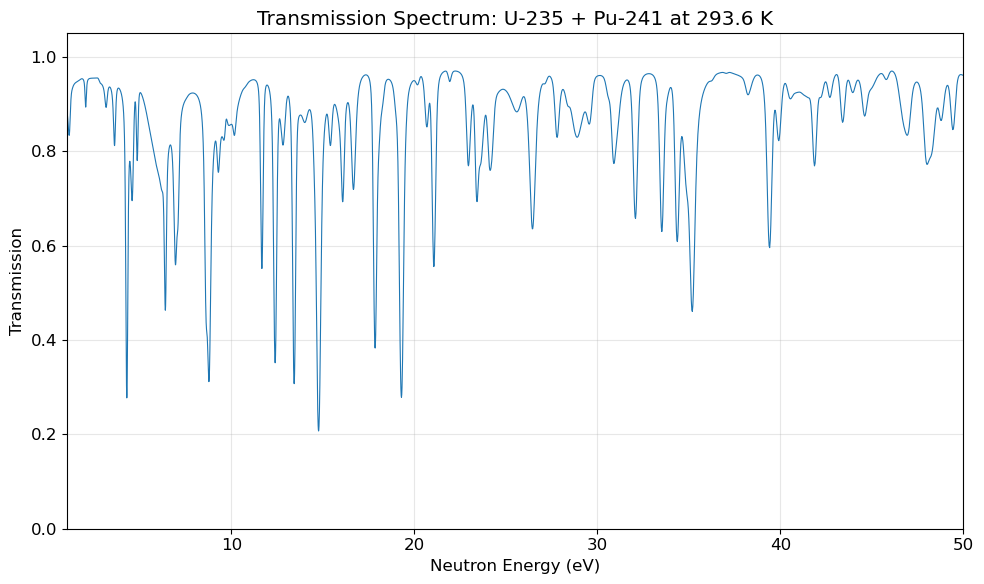

In [8]:
fig, ax = plt.subplots()
ax.plot(energies, transmission, linewidth=0.8)
ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Transmission Spectrum: U-235 + Pu-241 at 293.6 K')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 5. Multi-L Manual Construction with `create_resonance_data()`

The `create_resonance_data()` function now supports:
- **`target_spin`** — nuclear spin of the target (default 0.0)
- **`l_groups`** — list of `(l_value, [(E, J, Gn, Gg), ...])` tuples

This is useful when you have specific resonance parameters (e.g. from a SAMMY
analysis) rather than an ENDF file.

In [9]:
# Create U-238 with L=0 and L=1 resonances manually
u238_manual = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[],  # ignored when l_groups is provided
    target_spin=0.0,
    l_groups=[
        (0, [
            (6.674, 0.5, 1.493e-3, 23.0e-3),    # s-wave resonance
            (20.87, 0.5, 10.26e-3, 22.86e-3),   # another s-wave
            (36.68, 0.5, 33.55e-3, 23.36e-3),   # another s-wave
        ]),
        (1, [
            (10.23, 1.5, 0.002e-3, 24.0e-3),    # p-wave resonance
            (11.31, 0.5, 0.0002e-3, 24.0e-3),   # p-wave resonance
        ]),
    ]
)
print(u238_manual)
print(f"  L values: {u238_manual.l_values}")
print(f"  Target spin: {u238_manual.target_spin}")
print(f"  Resonances: {u238_manual.n_resonances}")

ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=5)
  L values: [0, 1]
  Target spin: 0.0
  Resonances: 5


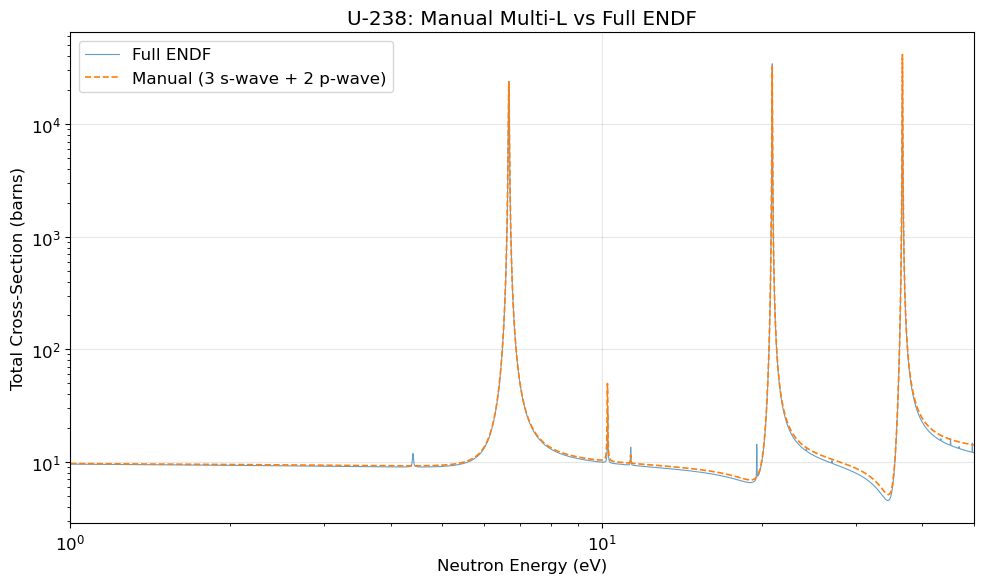

In [10]:
# Compare with ENDF data in the same energy range
E_compare = np.geomspace(1.0, 50.0, 5000)
xs_manual = nereids.cross_sections(E_compare, u238_manual)
xs_endf = nereids.cross_sections(E_compare, u238)

fig, ax = plt.subplots()
ax.loglog(E_compare, xs_endf['total'], label='Full ENDF', linewidth=0.8, alpha=0.7)
ax.loglog(E_compare, xs_manual['total'], '--', label='Manual (3 s-wave + 2 p-wave)',
          linewidth=1.2)

ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238: Manual Multi-L vs Full ENDF')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 50)
plt.tight_layout()
plt.show()

## 6. Loading from Local ENDF Files

If you have a local ENDF file (e.g. from a SAMMY analysis), use `load_endf_file()`.

The repo ships `examples/data/u238_ex027.endf` — a U-238 evaluation from the SAMMY
example suite (ex027) covering the resolved resonance region up to 10 keV with 1653
resonances.  It is a good reference for comparing an older evaluation against the
current IAEA default.

In [11]:
# Load the SAMMY ex027 U-238 ENDF file shipped with the repo.
# The file is at examples/data/u238_ex027.endf — copied from
# SAMMY/samexm_new/ex027_new/ex027.endf (1653 resonances, RRR up to 10 keV).
local_endf = str(_repo_root() / 'examples' / 'data' / 'u238_ex027.endf')

u238_sammy = nereids.load_endf_file(local_endf)
print(f"SAMMY ex027 ENDF: {u238_sammy}")
print(f"  L values:          {u238_sammy.l_values}")
print(f"  Scattering radius: {u238_sammy.scattering_radius:.6f} fm")
print(f"  Resonances:        {u238_sammy.n_resonances}")
print()
print("Comparison: IAEA ENDF/B-VIII.1 vs SAMMY ex027 evaluation")
print(f"  IAEA n_resonances: {u238.n_resonances}  |  SAMMY ex027: {u238_sammy.n_resonances}")
print(f"  IAEA AP (fm):      {u238.scattering_radius:.5f}  |  SAMMY ex027: {u238_sammy.scattering_radius:.5f}")

SAMMY ex027 ENDF: ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=1653)
  L values:          [0, 1]
  Scattering radius: 9.428480 fm
  Resonances:        1653

Comparison: IAEA ENDF/B-VIII.1 vs SAMMY ex027 evaluation
  IAEA n_resonances: 3345  |  SAMMY ex027: 1653
  IAEA AP (fm):      9.48000  |  SAMMY ex027: 9.42848


## 7. Supported Libraries and MAT Numbers

### ENDF Libraries

| Library | String | Notes |
|---------|--------|-------|
| ENDF/B-VIII.0 | `"endf8.0"` | Default, well-tested |
| ENDF/B-VIII.1 | `"endf8.1"` | Latest release (Aug 2024) |
| JEFF-3.3 | `"jeff3.3"` | European library |
| JENDL-5 | `"jendl5"` | Japanese library |

### Built-in MAT Numbers (535 isotopes)

`load_endf(z, a)` automatically resolves the MAT number for all 535 ground-state
isotopes in the ENDF/B-VIII.0 neutrons sublibrary (Z=0 through Z=100). The lookup
is provided by the `endf-mat` crate and requires no user input.

A few representative examples:

| Isotope | MAT | Isotope | MAT |
|---------|-----|---------|-----|
| H-1 | 125 | Zr-90 | 4025 |
| Li-6 | 325 | Nb-93 | 4125 |
| B-10 | 525 | Ag-107 | 4725 |
| C-12 | 625 | In-115 | 4931 |
| Al-27 | 1325 | Hf-177 | 7234 |
| Fe-56 | 2631 | Ta-181 | 7328 |
| Ni-58 | 2825 | W-184 | 7437 |
| Cu-63 | 2925 | Au-197 | 7925 |
| Sn-120 | 5049 | U-235 | 9228 |
| Th-232 | 9040 | U-238 | 9237 |

Provide `mat=` explicitly only for isotopes outside this set (e.g. metastable states).
Full table in [`crates/endf-mat/src/mat.rs`](../../crates/endf-mat/src/mat.rs).

## 8. Cross-Library Comparison

Different ENDF evaluations can disagree on resonance parameters — positions,
widths, and spin assignments are revised as new measurements become available.
Here we load U-238 from three libraries and compare the cross-sections near the
dominant 6.674 eV resonance.

In [12]:
libraries = {
    "endf8.1": "ENDF/B-VIII.1 (default)",
    "endf8.0": "ENDF/B-VIII.0",
    "jeff3.3": "JEFF-3.3",
}

# Load U-238 from each library (results are cached after the first download)
data_by_lib = {}
for lib, label in libraries.items():
    d = nereids.load_endf(92, 238, library=lib)
    data_by_lib[lib] = (d, label)
    print(f"{label:30s}  resonances={d.n_resonances}  "
          f"AP={d.scattering_radius:.5f} fm  I={d.target_spin}")

ENDF/B-VIII.1 (default)         resonances=3345  AP=9.48000 fm  I=0.0
ENDF/B-VIII.0                   resonances=3345  AP=9.48000 fm  I=0.0
JEFF-3.3                        resonances=3345  AP=9.48000 fm  I=0.0


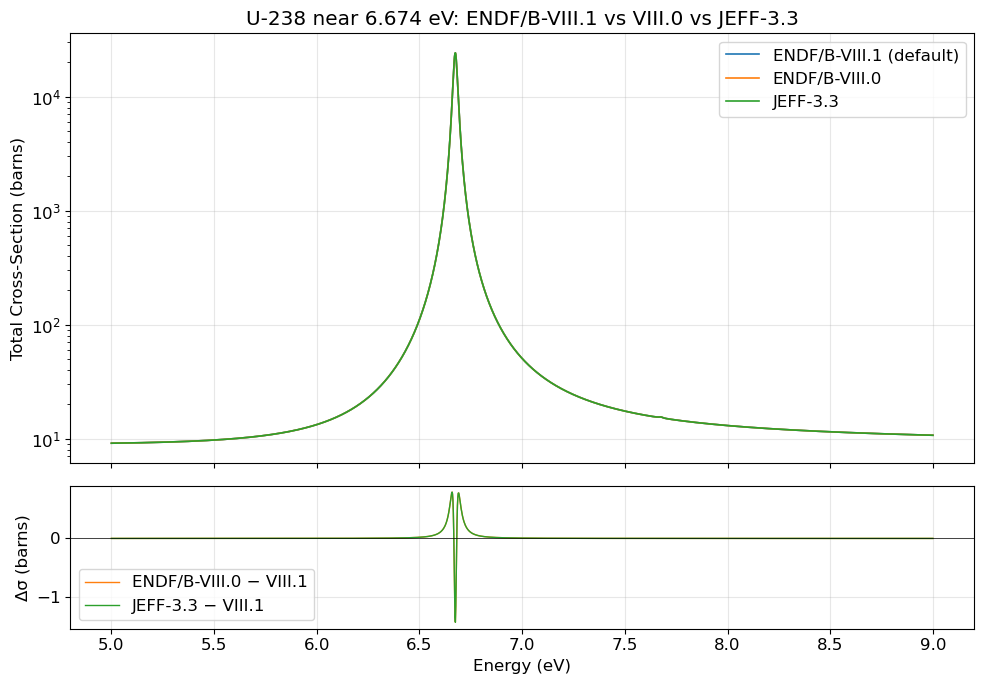

In [13]:
# Cross-section comparison near the 6.674 eV resonance
E_zoom = np.linspace(5.0, 9.0, 2000)

fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

colors = {'endf8.1': 'C0', 'endf8.0': 'C1', 'jeff3.3': 'C2'}

xs_ref = None
for lib, (d, label) in data_by_lib.items():
    xs = np.asarray(nereids.cross_sections(E_zoom, d)['total'])
    axes[0].semilogy(E_zoom, xs, label=label, color=colors[lib], linewidth=1.2)
    if lib == 'endf8.1':
        xs_ref = xs

# Residuals vs ENDF/B-VIII.1
for lib, (d, label) in data_by_lib.items():
    if lib == 'endf8.1':
        continue
    xs = np.asarray(nereids.cross_sections(E_zoom, d)['total'])
    axes[1].plot(E_zoom, xs - xs_ref, label=f'{label} − VIII.1', color=colors[lib], linewidth=1.0)

axes[0].set_ylabel('Total Cross-Section (barns)')
axes[0].set_title('U-238 near 6.674 eV: ENDF/B-VIII.1 vs VIII.0 vs JEFF-3.3')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Energy (eV)')
axes[1].set_ylabel('Δσ (barns)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Tabulate available summary parameters across libraries
print(f"{'Library':30s}  {'#res':>6}  {'AP (fm)':>10}  {'L values':>10}  {'I_target':>8}")
print("-" * 72)
for lib, (d, label) in data_by_lib.items():
    print(f"{label:30s}  {d.n_resonances:>6d}  {d.scattering_radius:>10.5f}  "
          f"{str(d.l_values):>10s}  {d.target_spin:>8.1f}")

# Spot-check cross-section at and near the 6.674 eV resonance peak
probe_energies = np.array([6.670, 6.674, 6.678, 20.87])
print()
print(f"{'Library':30s}  " + "  ".join(f"{e:.3f} eV" for e in probe_energies))
print("-" * 80)
for lib, (d, label) in data_by_lib.items():
    xs_vals = nereids.cross_sections(probe_energies, d)['total']
    row = "  ".join(f"{v:>9.1f}" for v in xs_vals)
    print(f"{label:30s}  {row}")
print("(Total cross-section in barns)")
print()
print("Note: differences reflect updated resonance evaluations between library versions.")

Library                           #res     AP (fm)    L values  I_target
------------------------------------------------------------------------
ENDF/B-VIII.1 (default)           3345     9.48000      [0, 1]       0.0
ENDF/B-VIII.0                     3345     9.48000      [0, 1]       0.0
JEFF-3.3                          3345     9.48000      [0, 1]       0.0

Library                         6.670 eV  6.674 eV  6.678 eV  20.870 eV
--------------------------------------------------------------------------------
ENDF/B-VIII.1 (default)           21504.5    24250.8    22233.2    38107.0
ENDF/B-VIII.0                     21503.8    24249.3    22232.3    38105.7
JEFF-3.3                          21503.8    24249.3    22232.3    38105.7
(Total cross-section in barns)

Note: differences reflect updated resonance evaluations between library versions.


## Summary

This notebook demonstrated:

1. **`load_endf(z, a)`** — one-line ENDF retrieval with IAEA download + local cache
2. **Full resonance spectra** — thousands of resonances across L=0 and L=1 groups
3. **Multi-isotope comparison** — U-238 vs Pu-241 side-by-side
4. **Realistic transmission** — full ENDF data with Doppler broadening
5. **`create_resonance_data(..., l_groups=)`** — manual multi-L construction
6. **`load_endf_file(path)`** — loading local ENDF files
7. **Library and MAT reference** — supported ENDF libraries and isotope table
8. **Cross-library comparison** — ENDF/B-VIII.1 vs VIII.0 vs JEFF-3.3; spot differences in resonance count and cross-section peak shape

**Next**: [03_spectrum_fitting.ipynb](03_spectrum_fitting.ipynb) — fitting measured spectra to recover isotopic compositions.